In [1]:
from scripts import s1_rvl, io
import matplotlib.pyplot as plt
import numpy as np
import os
from scripts.s1_io import (
    S1Annotation,
    find_safe_files,
    parse_annotation,
    read_slc_burst,
    slant_range_time_vector,
    _nearest_estimate,
)
%matplotlib widget

In [2]:
burst_idx = 9
slc = io.read_slc(f'data/S1_data/test2/iw1_vv_burst{burst_idx}.slc', f'data/S1_data/test2/iw1_vv_burst{burst_idx}.slc.par')

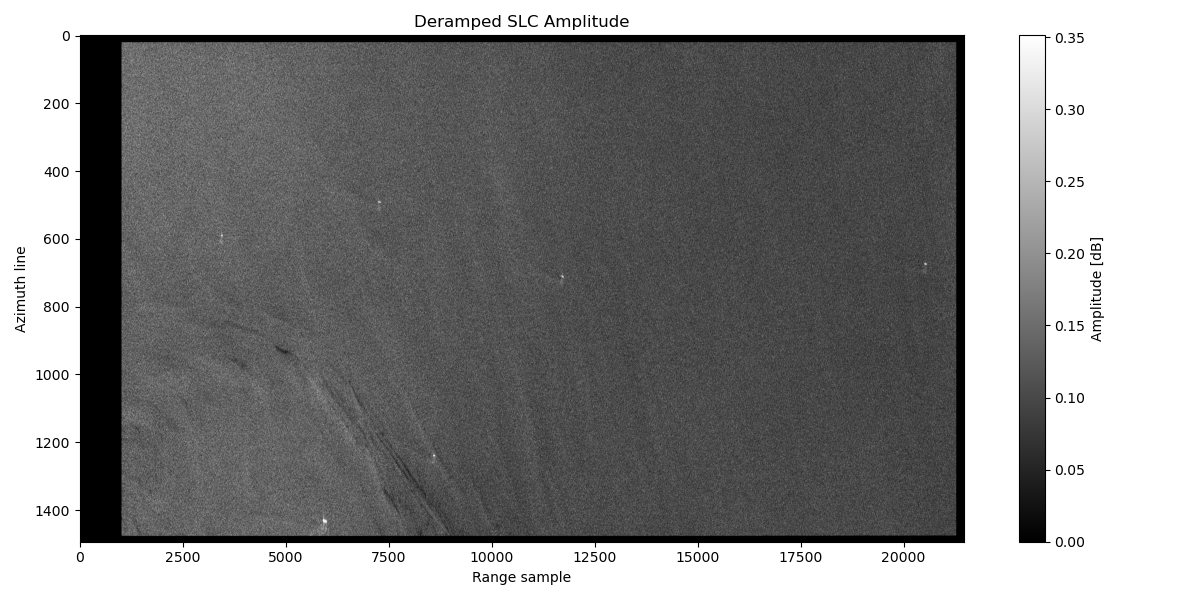

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))
img = ax.imshow(                                                                                                                                                                                                         
    np.abs(slc),     
    cmap='gray',                                                                                                                                                                                                         
    aspect='auto',
    vmin=np.nanpercentile(np.abs(slc), 5),                                                                                                                                                                                    
    vmax=np.nanpercentile(np.abs(slc), 99),                                                                                                                                                                                   
    origin='upper',
)                                                                                                                                                                                                                        
plt.colorbar(img, ax=ax, label='Amplitude [dB]')
ax.set_xlabel('Range sample')                                                                                                                                                                                            
ax.set_ylabel('Azimuth line')
ax.set_title('Deramped SLC Amplitude')                                                                                                                                                            
plt.tight_layout()                                                                                                                                                                                                       
plt.show()    

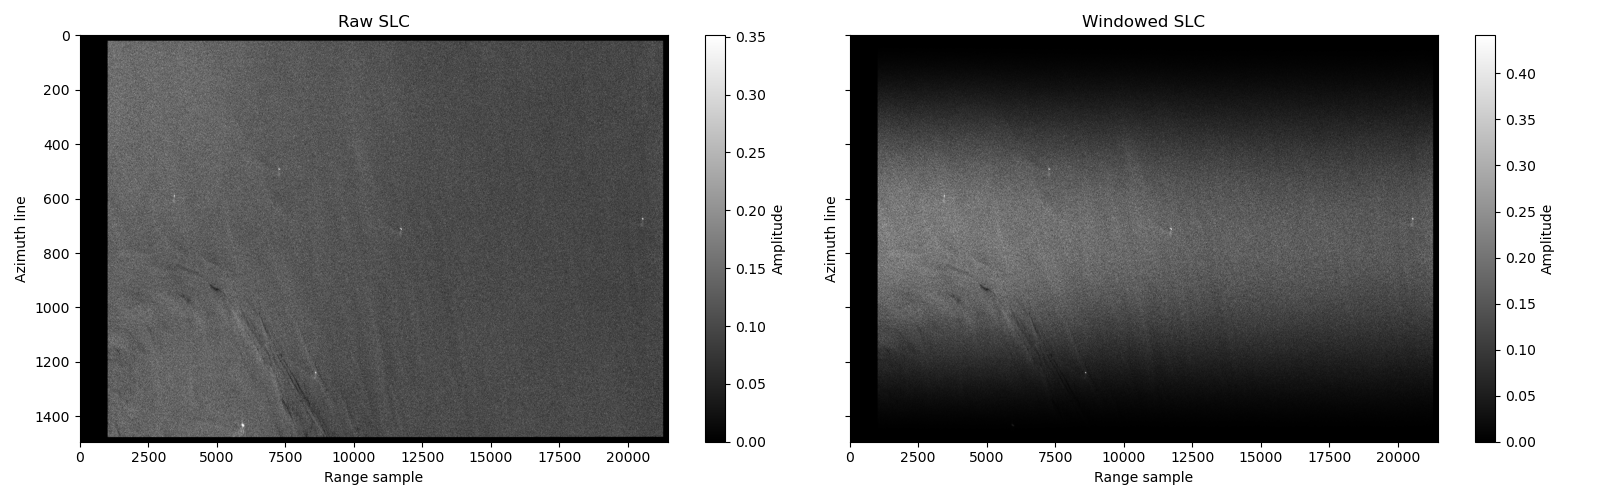

In [4]:
lpb = slc.shape[0]
w = s1_rvl._burst_hanning(lpb)                                                                                                                                        
slc_windowed = (slc * w[:, np.newaxis]).astype(np.complex64)

amp_raw = np.abs(slc)
amp_win = np.abs(slc_windowed)
                                                                                                                                                                                                                        
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
                                                                                                                                                                                                                        
for ax, arr, title in zip(axes, [amp_raw, amp_win], ['Raw SLC', 'Windowed SLC']):                                                                                                                                        
    vmin, vmax = np.nanpercentile(arr, 5), np.nanpercentile(arr, 99)
    im = ax.imshow(arr, cmap='gray', aspect='auto', origin='upper', vmin=vmin, vmax=vmax)                                                                                                                                
    ax.set_xlabel('Range sample')                                                                                                                                                                                        
    ax.set_ylabel('Azimuth line')
    ax.set_title(title)                                                                                                                                                                                                  
    plt.colorbar(im, ax=ax, label='Amplitude')                                                                                                                                                                           

plt.tight_layout()                                                                                                                                                                                                       
plt.show()   

In [5]:
data_dir = 'data/S1_data/test2'

slc_paths     = sorted(f'{data_dir}/{f}' for f in os.listdir(data_dir) if f.endswith('.slc'))
slc_par_paths = sorted(f'{data_dir}/{f}' for f in os.listdir(data_dir) if f.endswith('.slc.par'))

In [ ]:
merged = s1_rvl.merge_gamma_bursts(slc_paths, slc_par_paths)

Merged image shape: (12233, 21464)
Expected (naive concat): 13446 lines  →  overlap removed: 1213 lines


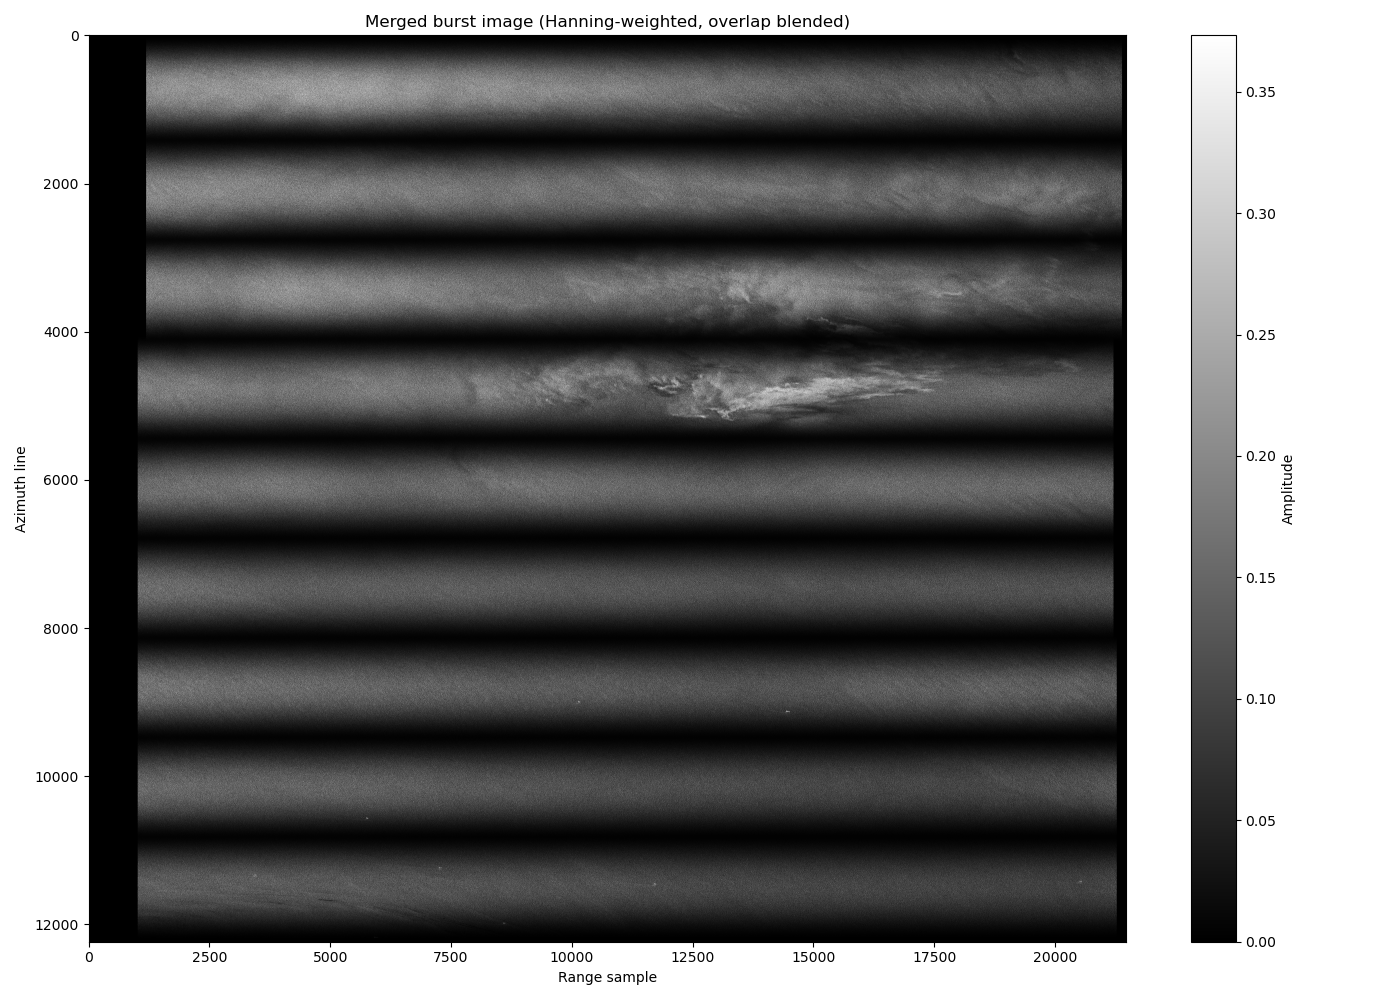

In [7]:
fig, ax = plt.subplots(figsize=(14, 10))
amp = np.abs(merged)
im = ax.imshow(
    amp,
    cmap='gray',
    aspect='auto',
    origin='upper',
    vmin=np.nanpercentile(amp, 5),
    vmax=np.nanpercentile(amp, 99),
)
plt.colorbar(im, ax=ax, label='Amplitude')
ax.set_xlabel('Range sample')
ax.set_ylabel('Azimuth line')
ax.set_title('Merged burst image (Hanning-weighted, overlap blended)')
plt.tight_layout()
plt.show()

In [18]:
p0, p1, az_centers, rg_centers = s1_rvl.estimate_correlation_grid(slc, block_az=256, block_rg=512, stride_az=8, stride_rg=64)

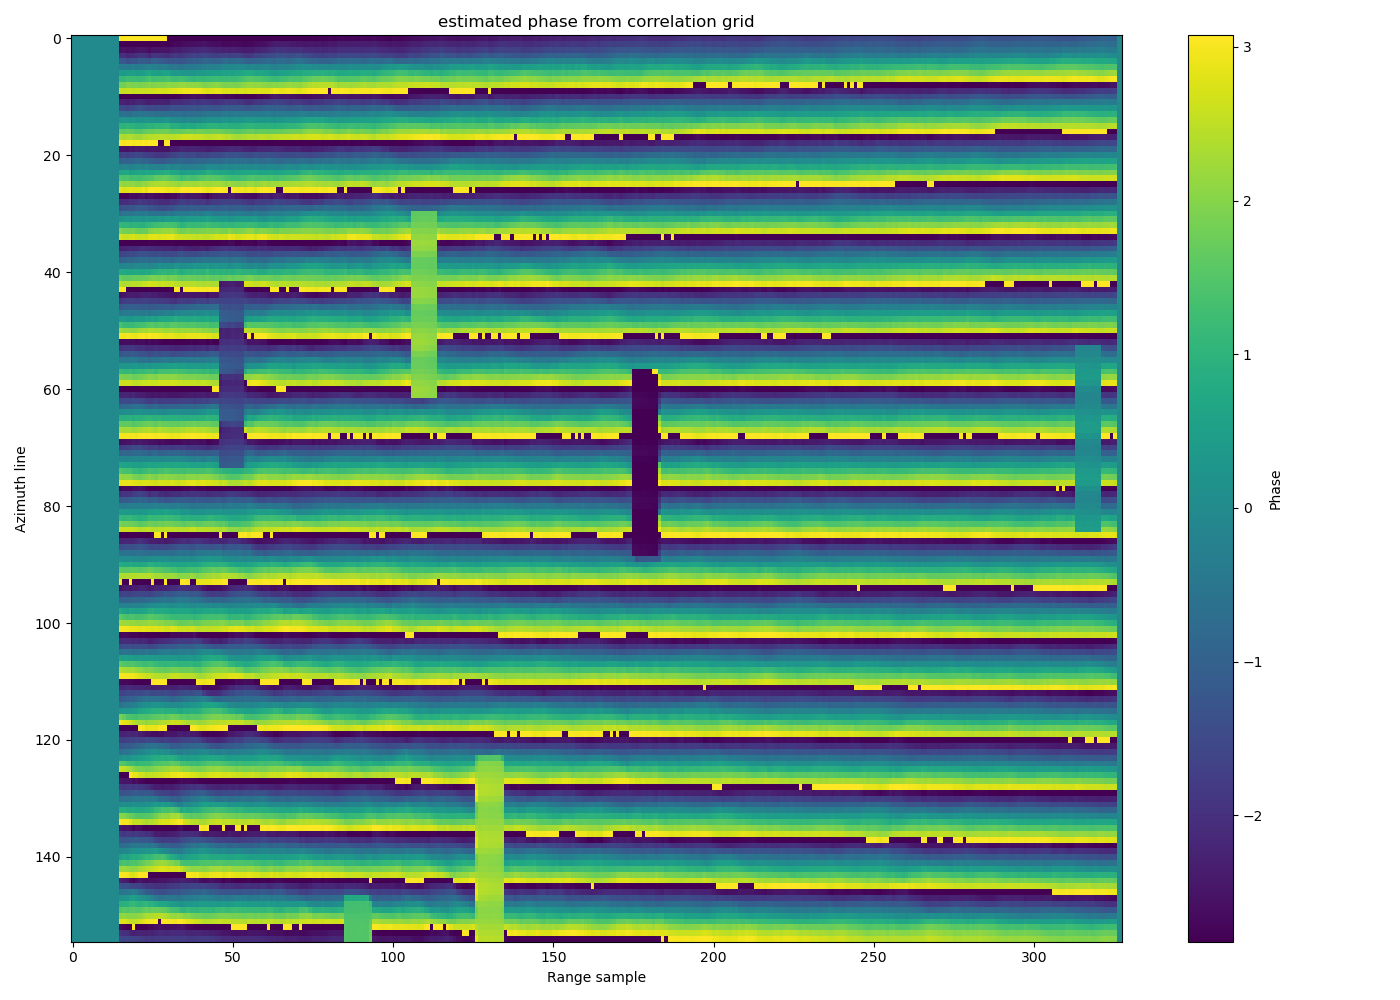

In [19]:
fig, ax = plt.subplots(figsize=(14, 10))
amp = np.angle(p1)
im = ax.imshow(
    amp,
    cmap='viridis',
    aspect='auto',
    origin='upper',
    vmin=np.nanpercentile(amp, 5),
    vmax=np.nanpercentile(amp, 99),
)
plt.colorbar(im, ax=ax, label='Phase')
ax.set_xlabel('Range sample')
ax.set_ylabel('Azimuth line')
ax.set_title('estimated phase from correlation grid')
plt.tight_layout()
plt.show()

In [20]:
annot = parse_annotation('data/S1_data/test2/S1A_IW_SLC__1SDV_20260205T165251_20260205T165321_063086_07EAEF_2642.SAFE/annotation/s1a-iw1-slc-vv-20260205t165251-20260205t165319-063086-07eaef-004.xml')

In [21]:
f_dc, _, snr = s1_rvl.correlation_to_doppler(p0, p1, annot.prf, annot.wavelength)

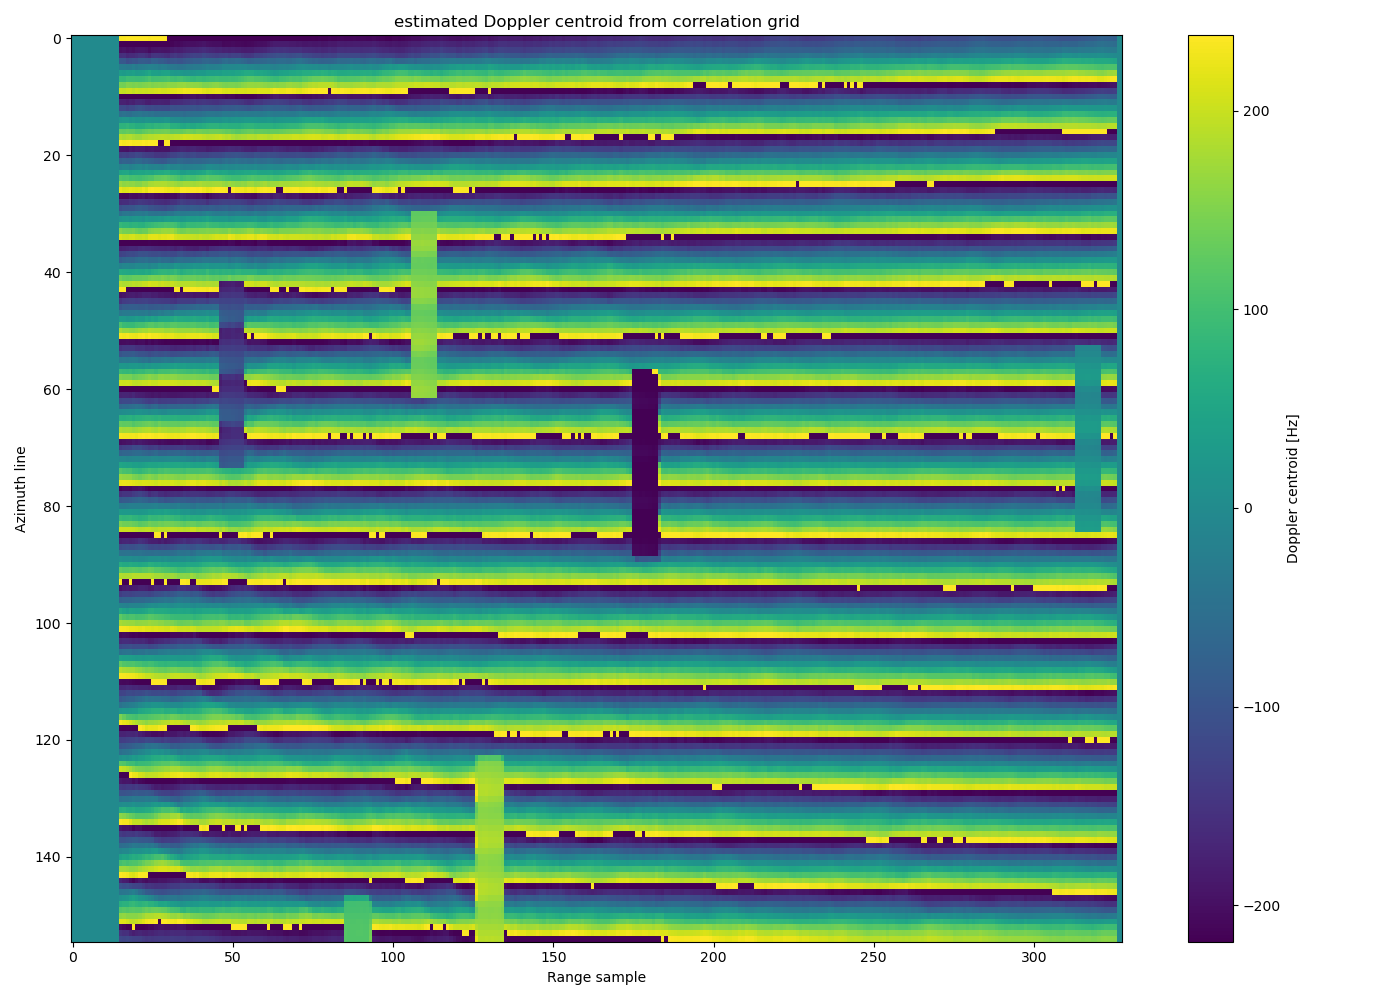

In [22]:
fig, ax = plt.subplots(figsize=(14, 10))
amp = f_dc
im = ax.imshow(
    amp,
    cmap='viridis',
    aspect='auto',
    origin='upper',
    vmin=np.nanpercentile(amp, 5),
    vmax=np.nanpercentile(amp, 99),
)
plt.colorbar(im, ax=ax, label='Doppler centroid [Hz]')
ax.set_xlabel('Range sample')
ax.set_ylabel('Azimuth line')
ax.set_title('estimated Doppler centroid from correlation grid')
plt.tight_layout()
plt.show()

In [13]:
par = io.parse_slc_par('data/S1_data/test2/iw1_vv_burst8.slc.par')                                                                                                                                                                                                 
dr = float(par['range_pixel_spacing'][0])                                                                                                                                                                                                
coeffs = [float(x) for x in par['doppler_polynomial'][:4]]                                                                                                                                                                               
print('doppler_polynomial coeffs:', coeffs)   

doppler_polynomial coeffs: [26.78255, -0.000602781, 3.1298e-09, 2.79983e-25]


In [14]:
rg_m = rg_centers * dr                                                                                                                                                                                                                   
f_geom = sum(c * rg_m**k for k, c in enumerate(coeffs))                                                                                                                                                                                  
print('f_geom range:', f_geom.min(), 'to', f_geom.max(), 'Hz')

f_geom range: 4.657857144796029 to 26.42418390563634 Hz


In [15]:
f_dca = f_dc - f_geom[np.newaxis, :]  

In [16]:
plt.imshow(f_dca, aspect='auto')

In [17]:
fin = s1_rvl.compute_rvl_gamma(['data/S1_data/test2/iw1_vv_burst8.slc'], ['data/S1_data/test2/iw1_vv_burst8.slc.par'], 'data/S1_data/test2/S1A_IW_SLC__1SDV_20260205T165251_20260205T165321_063086_07EAEF_2642.SAFE/annotation/s1a-iw1-slc-vv-20260205t165251-20260205t165319-063086-07eaef-004.xml', stride_az=64, stride_rg=128)